In [ ]:
# Special Studies: Computer Vision (CSE 40535)
# Practical 05: Generative diffusion denoising models
# University of Notre Dame
# ____________________________________________________________
# Rasel Ahmed Bhuiyan, Adam Czajka, Walter Scheirer April 2025

## Your tasks for today:

1. Look for *** TASK 1 *** in the code and add a single line that implements the correct forward diffusion process (50 points)

2. Look for *** TASK 2 *** in the code and add a single line that implements the correct reverse diffusion process (50 points)

3. Look for *** TASK 3 *** in the code and experiment with the number of **reverse diffusion steps**. If you decrease that number (below now-default 1000 steps), what happens and why? If you increase that number (above now-default 1000 steps), what happens and why (and how to fix this)? (50 points)

Your answer to Task 3: We are doing reverse diffusion steps on the MNIST 0-9 numbers. When we reduce the number of denoise steps the resulting images still have tons of noise and are blurry. This is because the model has not ran through enough denoising steps in order to construct an image that is readable.This is because the modle was trained assuming 1000 denoising steps, so fewer steps means each step has to "undo" more noise thatn it was trianed to handle. Thus this explains why running the model of fewer than 1000 denoising steps results in blurry and noisy images.

Additionally, if you increase the number above 1000 steps the image becomes denoised then disappears, ultimately turning into a blank image. This again is because the model was trained to denoise for 1000 timesteps and anything beyond that is sort of undefined behavior. The undefined behavior I believe is that the model starts to treat the clean image itself as noise, hence the blank result. The fix would to either use the 1000 timesteps the model was trained on. Additionally, we could trian the model to handle a longer scheulder e.g 2000.

4. The synthesized images (taken directly from the model) are ... well, okay-ish. Some of them look quite good, and many of them are clear out-of-set samples. Provide an idea for **sampling from a generative model**. That is, what strategy would you put on top of the raw model's output to maximize the probability of generating within-set samples? (50 points)

Your answer to Task 4:
The model can take ideas from cVAE and cGAN, and take input vector conditioning the model to a specific class or group of classes (0-9). This embedded vector in the model should be passed in every denoising step to condition the model. As described in the other conditioned models, this conditions the models to select and produce images that are in the known distribution. Hopefully, this idea is able to sample from a generative modela nd produce the correct samples rather than out-of-set samples.

Another idea is to train a separate classifer, kinda of like GANs with the generator and discriminator. The classifer at each denoising step nudges the socre function toward high-probability regions of the desired class.

## What to deliver?

As usual: work in your copied notebook, share your copy with everyone at Notre Dame, and email your link to Louisa.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from IPython.display import clear_output
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import math
import os
from tqdm import tqdm
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load MNIST Dataset

In [4]:
# Data loading
image_size = 28
batch_size = 64

transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
print(f"Number of batches in train_loader: {len(train_loader)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.44MB/s]

Number of batches in train_loader: 157


# Display Samples

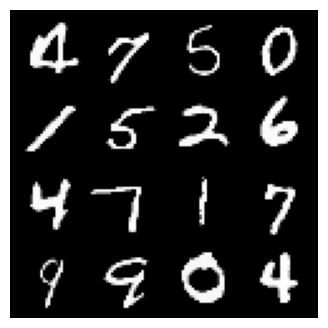

In [5]:
def show_images_from_loader(loader, num_images=16):
    # Get a batch of data from the loader
    images, labels = next(iter(loader))

    # Create a grid of images (num_images x num_images)
    grid_img = torchvision.utils.make_grid(images[:num_images], nrow=4, padding=2)

    # Convert the grid to a NumPy array and move channels to last dimension for plotting
    np_grid_img = grid_img.permute(1, 2, 0).numpy()

    # Normalize the image for plotting
    np_grid_img = np.clip(np_grid_img, 0, 1)

    # Display the image grid
    plt.figure(figsize=(4, 4))
    plt.imshow(np_grid_img)
    plt.axis('off')
    plt.show()

# Display images
show_images_from_loader(train_loader)

# Overview of diffusion forward and reverse process

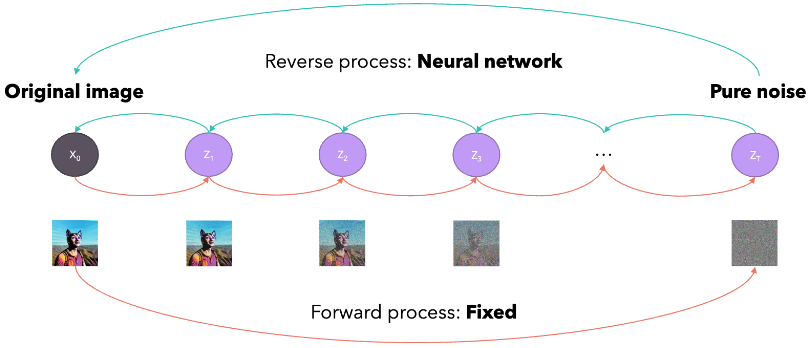

**Forward Process (Diffusion Process):** The forward process gradually adds Gaussian noise to the data over multiple time steps. This step-by-step corruption transforms the data into pure noise, making it indistinguishable from random noise by the final step.

**Reverse Process (Denoising Process):** The reverse process involves two steps:
* **Noise Prediction:** A neural network will train to predict the noise added to the data at each time step.

* **Denoising:** The predicted noise is subtracted from the noisy image at each step to iteratively reconstruct the original data.

# DDPM Forward Process (Adding Noise)

## Formula for generating noisy image

In [6]:
class DDPMForwardProcess:
    """
    Class for the forward diffusion process.
    This process gradually adds noise to an image in a series of steps, controlled by
    a variance schedule, represented by `betas`.
    """

    def __init__(self, num_time_steps=1000, beta_start=1e-4, beta_end=0.02):
        """
        Initializes the forward diffusion process.

        Parameters:
        - num_time_steps: int, the total number of steps in the diffusion process.
        - beta_start: float, the initial value of beta (noise variance).
        - beta_end: float, the final value of beta (noise variance).
        """
        # Linearly spaced noise variance schedule
        self.betas = torch.linspace(beta_start, beta_end, num_time_steps)

        # Calculate the alpha values (1 - beta)
        self.alphas = 1 - self.betas

        # Compute cumulative product of alphas for each time step
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

        # Precompute square roots of alpha bars and (1 - alpha bars) for efficiency
        self.sqrt_alpha_bars = torch.sqrt(self.alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1 - self.alpha_bars)

    def add_noise(self, x_start, noise, t):
        """
        Adds noise to the starting image at a specific timestep.

        Parameters:
        - x_start: tensor, the original (clean) image.
        - noise: tensor, the noise to add to the image.
        - t: int, the current timestep (index in the diffusion process).

        Returns:
        - tensor, the noisy image at timestep t.
        """
        # Select precomputed alpha bar and (1 - alpha bar) values for the given timestep
        sqrt_alpha_bar_t = self.sqrt_alpha_bars.to(x_start.device)[t]
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_bars.to(x_start.device)[t]

        # Reshape to match the image dimensions for broadcasting
        sqrt_alpha_bar_t = sqrt_alpha_bar_t[:, None, None, None]
        sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar_t[:, None, None, None]

        # *** TASK 1 *** (Forward diffusion process)
        # Generate noisy image by linearly combining the original image and noise
        xt = sqrt_alpha_bar_t*x_start + sqrt_one_minus_alpha_bar_t * noise


        return xt

# Test DDPM forward process

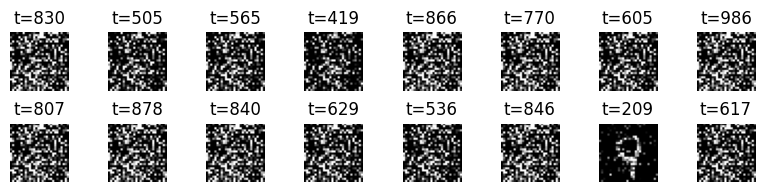

In [7]:
# Get a batch of images from the dataset
images, labels = next(iter(train_loader))

# Initialize the DDPM forward process
ddpmfp = DDPMForwardProcess(num_time_steps=1000, beta_start=1e-4, beta_end=0.02)

# Take the first image
x_start = images[0].unsqueeze(0)

# Generate random noise of the same size as the image batch
noise = torch.randn_like(x_start)

# time steps
time_steps = torch.randint(0, 1000, (batch_size,))

noisy_images = ddpmfp.add_noise(x_start, noise, time_steps)

# Plot the first few noisy images from the batch
fig, axes = plt.subplots(2, 8, figsize=(8, 2))

for i in range(16):
    noisy_image_np = noisy_images[i].permute(1, 2, 0).detach().numpy()
    noisy_image_np = np.clip(noisy_image_np, 0, 1)

    # Plot the noisy image
    ax = axes[i // 8, i % 8]
    ax.imshow(noisy_image_np, cmap='gray')
    ax.axis('off')
    ax.set_title(f"t={time_steps[i].item()}")

plt.tight_layout()
plt.show()

# DDPM Reverse Process (Denoising)

## Equation for reversing the effect of the added noise at timestep `t` to recover an estimate of the original image `x0`:

In [8]:
class DDPMReverseProcess:
    """
    Class for the reverse diffusion process in Denoising Diffusion Probabilistic Models (DDPM).
    This process gradually denoises an image by reversing the forward process.
    """

    def __init__(self, num_time_steps=1000, beta_start=1e-4, beta_end=0.02):
        """
        Initializes the reverse diffusion process with a specified beta schedule.

        Parameters:
        - num_time_steps: Number of timesteps in the diffusion process.
        - beta_start: The starting value of the beta schedule.
        - beta_end: The ending value of the beta schedule.
        """
        # Beta schedule: Linearly spaced values between beta_start and beta_end
        self.beta = torch.linspace(beta_start, beta_end, num_time_steps)  # b -> beta (noise schedule)

        # Alpha values: Complement of beta values
        self.alpha = 1 - self.beta  # a -> alpha

        # Cumulative product of alphas (alpha_bar)
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)  # a_bar -> cumulative product of alpha

    def sample_prev_timestep(self, xt, noise_pred, t):
        """
        Samples the previous timestep image (x_{t-1}) from the current noisy image (x_t)
        and its predicted noise.

        Parameters:
        - xt: Current noisy image at timestep t (batch, channels, height, width).
        - noise_pred: The predicted noise at timestep t (batch, channels, height, width).
        - t: The current timestep t.

        Returns:
        - x_prev: The sampled image at the previous timestep (x_{t-1}).
        - x0: The estimated clean image (x_0).
        """

        # Select precomputed alpha bar and (1 - alpha bar) values for the given timestep
        alpha_bar_t = self.alpha_bar.to(xt.device)[t]

        # *** TASK 2 *** (Reverse diffusion process)
        # Calculate x0, the clean image estimate at t=0, from xt and the predicted noise
        x0 = (xt-(torch.sqrt(1 - alpha_bar_t)*noise_pred)) / torch.sqrt(alpha_bar_t)

        # Clamp values
        x0 = torch.clamp(x0, -1., 1.)

        # Calculate mean (x_{t-1}) for the reverse diffusion process
        mean = (xt - ((1 - self.alpha.to(xt.device)[t]) * noise_pred) / torch.sqrt(1 - self.alpha_bar.to(xt.device)[t]))
        mean = mean / torch.sqrt(self.alpha.to(xt.device)[t])  # Normalize by alpha

        # If t == 0, no further diffusion steps are needed, return mean and x0
        if t == 0:
            return mean, x0
        else:
            # Otherwise, sample variance for noise in the reverse process
            variance = (1 - self.alpha_bar.to(xt.device)[t-1]) / (1 - self.alpha_bar.to(xt.device)[t])
            variance = variance * self.beta.to(xt.device)[t]  # Adjust variance based on beta
            sigma = variance ** 0.5  # Standard deviation (sqrt of variance)

            # Generate random noise for sampling
            z = torch.randn(xt.shape).to(xt.device)

            # Return the noisy sample from the previous timestep
            return mean + sigma * z, x0

In [11]:
# Test Reverse Process
xt = torch.randn(1, 1, 28, 28)
noise_pred = torch.randn(1, 1, 28, 28)
t = torch.randint(0, 1000, (1,))

ddpmrp = DDPMReverseProcess()
xt, x0 = ddpmrp.sample_prev_timestep(xt, noise_pred, t)
xt.shape

torch.Size([1, 1, 28, 28])

# Model Utils (just run this cell)

In [12]:

def get_time_embedding(time_steps: torch.Tensor, t_emb_dim: int) -> torch.Tensor:
    """
    Transform a scalar time-step into a vector representation of size t_emb_dim.

    :param time_steps: 1D tensor of size (Batch,)
    :param t_emb_dim: Embedding Dimension (e.g., 128)

    :return: Tensor of size (Batch, t_emb_dim)
    """
    assert t_emb_dim % 2 == 0, "Time embedding dimension must be divisible by 2."

    # Factor for time embedding (scaling the time steps)
    factor = 2 * torch.arange(0, t_emb_dim // 2, dtype=torch.float32, device=time_steps.device) / t_emb_dim
    factor = 10000 ** factor

    # Normalize time steps and apply the embedding
    t_emb = time_steps[:, None] / factor  # (B, 1) -> (B, t_emb_dim // 2)
    t_emb = torch.cat([torch.sin(t_emb), torch.cos(t_emb)], dim=1)  # (B, t_emb_dim)

    return t_emb



class NormActConv(nn.Module):
    """
    Performs GroupNorm, Activation, and Convolution operations.
    """
    def __init__(self, in_channels: int, out_channels: int, num_groups: int = 8,
                 kernel_size: int = 3, norm: bool = True, act: bool = True):
        super(NormActConv, self).__init__()

        # GroupNorm
        self.g_norm = nn.GroupNorm(num_groups, in_channels) if norm else nn.Identity()

        # Activation (SiLU by default)
        self.act = nn.SiLU() if act else nn.Identity()

        # Convolution
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size,
                              padding=(kernel_size - 1) // 2)

    def forward(self, x):
        x = self.g_norm(x)
        x = self.act(x)
        x = self.conv(x)
        return x


class TimeEmbedding(nn.Module):
    """
    Maps Time Embedding to the required output dimension.
    """
    def __init__(self, n_out: int, t_emb_dim: int = 128):
        super(TimeEmbedding, self).__init__()
        self.te_block = nn.Sequential(
            nn.SiLU(),
            nn.Linear(t_emb_dim, n_out)
        )

    def forward(self, x):
        return self.te_block(x)



class SelfAttentionBlock(nn.Module):
    """
    Applies GroupNorm and Multiheaded Self Attention operation.
    """
    def __init__(self, num_channels: int, num_groups: int = 8, num_heads: int = 4, norm: bool = True):
        super(SelfAttentionBlock, self).__init__()

        # GroupNorm
        self.g_norm = nn.GroupNorm(num_groups, num_channels) if norm else nn.Identity()

        # Self-Attention
        self.attn = nn.MultiheadAttention(num_channels, num_heads, batch_first=True)

    def forward(self, x):
        batch_size, channels, h, w = x.shape
        x = x.reshape(batch_size, channels, h * w)  # Flatten height and width
        x = self.g_norm(x)
        x = x.transpose(1, 2)  # Prepare for multihead attention
        x, _ = self.attn(x, x, x)  # Apply self-attention
        x = x.transpose(1, 2).reshape(batch_size, channels, h, w)  # Reshape back to (B, C, H, W)
        return x



class Downsample(nn.Module):
    """
    Performs downsampling by the factor of k across height and width.
    """
    def __init__(self, in_channels: int, out_channels: int, k: int = 2,
                 use_conv: bool = True, use_mpool: bool = True):
        super(Downsample, self).__init__()

        self.use_conv = use_conv
        self.use_mpool = use_mpool

        # Downsampling using Convolution
        self.cv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=1),
            nn.Conv2d(in_channels, out_channels // 2 if use_mpool else out_channels,
                      kernel_size=4, stride=k, padding=1)
        ) if use_conv else nn.Identity()

        # Downsampling using Maxpool
        self.mpool = nn.Sequential(
            nn.MaxPool2d(k, k),
            nn.Conv2d(in_channels, out_channels // 2 if use_conv else out_channels,
                      kernel_size=1, stride=1, padding=0)
        ) if use_mpool else nn.Identity()

    def forward(self, x):
        if not self.use_conv:
            return self.mpool(x)

        if not self.use_mpool:
            return self.cv(x)

        return torch.cat([self.cv(x), self.mpool(x)], dim=1)



class Upsample(nn.Module):
    """
    Performs upsampling by the factor of k across height and width.
    """
    def __init__(self, in_channels: int, out_channels: int, k: int = 2,
                 use_conv: bool = True, use_upsample: bool = True):
        super(Upsample, self).__init__()

        self.use_conv = use_conv
        self.use_upsample = use_upsample

        # Upsampling using ConvTranspose
        self.cv = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels // 2 if use_upsample else out_channels,
                               kernel_size=4, stride=k, padding=1),
            nn.Conv2d(out_channels // 2 if use_upsample else out_channels,
                      out_channels // 2 if use_upsample else out_channels,
                      kernel_size=1, stride=1, padding=0)
        ) if use_conv else nn.Identity()

        # Upsampling using nn.Upsample
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=k, mode='bilinear', align_corners=False),
            nn.Conv2d(in_channels, out_channels // 2 if use_conv else out_channels,
                      kernel_size=1, stride=1, padding=0)
        ) if use_upsample else nn.Identity()

    def forward(self, x):
        if not self.use_conv:
            return self.up(x)

        if not self.use_upsample:
            return self.cv(x)

        return torch.cat([self.cv(x), self.up(x)], dim=1)



class DownC(nn.Module):
    """
    Performs Down-convolution with several operations like:
    Conv + TimeEmbedding, Self-Attention, Skip-Connections, Downsampling.
    """
    def __init__(self, in_channels: int, out_channels: int, t_emb_dim: int = 128,
                 num_layers: int = 2, down_sample: bool = True):
        super(DownC, self).__init__()

        self.num_layers = num_layers

        # Define layers
        self.conv1 = nn.ModuleList([NormActConv(in_channels if i == 0 else out_channels, out_channels) for i in range(num_layers)])
        self.conv2 = nn.ModuleList([NormActConv(out_channels, out_channels) for _ in range(num_layers)])
        self.te_block = nn.ModuleList([TimeEmbedding(out_channels, t_emb_dim) for _ in range(num_layers)])
        self.attn_block = nn.ModuleList([SelfAttentionBlock(out_channels) for _ in range(num_layers)])
        self.down_block = Downsample(out_channels, out_channels) if down_sample else nn.Identity()
        self.res_block = nn.ModuleList([nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1) for i in range(num_layers)])

    def forward(self, x, t_emb):
        out = x
        for i in range(self.num_layers):
            resnet_input = out

            # Resnet Block
            out = self.conv1[i](out)
            out = out + self.te_block[i](t_emb)[:, :, None, None]
            out = self.conv2[i](out)
            out = out + self.res_block[i](resnet_input)

            # Self-Attention Block
            out_attn = self.attn_block[i](out)
            out = out + out_attn

        out = self.down_block(out)
        return out


class MidC(nn.Module):
    """
    Refines the features obtained from the DownC block by applying a series of operations:

    1. A ResNet block with time embedding.
    2. A sequence of Self-Attention blocks followed by ResNet blocks with time embeddings.
    """

    def __init__(self,
                 in_channels: int,        # Number of input channels
                 out_channels: int,       # Number of output channels
                 t_emb_dim: int = 128,    # Time embedding dimension
                 num_layers: int = 2      # Number of layers in the mid block
                ):
        super(MidC, self).__init__()

        # Number of layers in the block
        self.num_layers = num_layers

        # List of convolutional layers for each block
        self.conv1 = nn.ModuleList([
            NormActConv(in_channels if i == 0 else out_channels,
                        out_channels
                       ) for i in range(num_layers + 1)
        ])

        # Second list of convolutional layers for each block
        self.conv2 = nn.ModuleList([
            NormActConv(out_channels,
                        out_channels
                       ) for _ in range(num_layers + 1)
        ])

        # Time embedding blocks, one for each layer
        self.te_block = nn.ModuleList([
            TimeEmbedding(out_channels, t_emb_dim) for _ in range(num_layers + 1)
        ])

        # Self-attention blocks for each layer
        self.attn_block = nn.ModuleList([
            SelfAttentionBlock(out_channels) for _ in range(num_layers)
        ])

        # Residual convolution blocks for each layer
        self.res_block = nn.ModuleList([
            nn.Conv2d(
                in_channels if i == 0 else out_channels,
                out_channels,
                kernel_size=1
            ) for i in range(num_layers + 1)
        ])

    def forward(self, x, t_emb):
        """
        Forward pass through the MidC block.

        Args:
        - x: Input tensor from the DownC block.
        - t_emb: Time embedding tensor.

        Returns:
        - out: The refined output tensor after applying all operations.
        """

        out = x

        # First ResNet block (without self-attention)
        resnet_input = out
        out = self.conv1[0](out)  # First convolution
        out = out + self.te_block[0](t_emb)[:, :, None, None]  # Add time embedding
        out = self.conv2[0](out)  # Second convolution
        out = out + self.res_block[0](resnet_input)  # Add residual connection

        # Sequence of Self-Attention + ResNet blocks
        for i in range(self.num_layers):
            # Self-Attention
            out_attn = self.attn_block[i](out)
            out = out + out_attn  # Add self-attention output to the main output

            # ResNet Block
            resnet_input = out
            out = self.conv1[i + 1](out)  # First convolution of the block
            out = out + self.te_block[i + 1](t_emb)[:, :, None, None]  # Add time embedding
            out = self.conv2[i + 1](out)  # Second convolution
            out = out + self.res_block[i + 1](resnet_input)  # Add residual connection

        return out

class UpC(nn.Module):
    """
    The UpC block is responsible for upsampling the features and refining them through
    convolutional, self-attention, and residual blocks, and also incorporates time embedding.
    It performs the following operations:

    1. Upsampling (if specified).
    2. Concatenation with the downsampled features.
    3. A series of ResNet blocks with time embeddings.
    4. Self-attention blocks for feature refinement.
    """

    def __init__(self,
                 in_channels: int,         # Number of input channels
                 out_channels: int,        # Number of output channels
                 t_emb_dim: int = 128,     # Time embedding dimension
                 num_layers: int = 2,      # Number of layers in the block
                 up_sample: bool = True    # Whether to apply upsampling
                ):
        super(UpC, self).__init__()

        self.num_layers = num_layers

        # List of convolutional layers (conv1) for each block
        self.conv1 = nn.ModuleList([
            NormActConv(in_channels if i == 0 else out_channels,
                        out_channels
                       ) for i in range(num_layers)
        ])

        # List of second convolutional layers (conv2) for each block
        self.conv2 = nn.ModuleList([
            NormActConv(out_channels,
                        out_channels
                       ) for _ in range(num_layers)
        ])

        # Time embedding blocks, one for each layer
        self.te_block = nn.ModuleList([
            TimeEmbedding(out_channels, t_emb_dim) for _ in range(num_layers)
        ])

        # Self-attention blocks for each layer
        self.attn_block = nn.ModuleList([
            SelfAttentionBlock(out_channels) for _ in range(num_layers)
        ])

        # Upsampling block if required, otherwise Identity operation
        self.up_block = Upsample(in_channels, in_channels // 2) if up_sample else nn.Identity()

        # Residual convolution blocks for each layer
        self.res_block = nn.ModuleList([
            nn.Conv2d(
                in_channels if i == 0 else out_channels,
                out_channels,
                kernel_size=1
            ) for i in range(num_layers)
        ])

    def forward(self, x, down_out, t_emb):
        """
        Forward pass through the UpC block.

        Args:
        - x: Input tensor (from the previous layer).
        - down_out: Output from the downsample block, for skip connection.
        - t_emb: Time embedding tensor.

        Returns:
        - out: Refined output tensor after upsampling and feature refinement.
        """

        # 1. Upsampling (if required)
        x = self.up_block(x)

        # 2. Concatenate the upsampled input with the downsampled output (skip connection)
        x = torch.cat([x, down_out], dim=1)

        out = x
        # 3. Iterate through the layers of the block
        for i in range(self.num_layers):
            resnet_input = out

            # 3.1 ResNet Block
            out = self.conv1[i](out)  # First convolution in the ResNet block
            out = out + self.te_block[i](t_emb)[:, :, None, None]  # Add time embedding
            out = self.conv2[i](out)  # Second convolution in the ResNet block
            out = out + self.res_block[i](resnet_input)  # Add residual connection

            # 3.2 Self-Attention Block
            out_attn = self.attn_block[i](out)
            out = out + out_attn  # Add self-attention output to the main output

        return out

# U-Net Model Architecture

In [13]:
class Unet(nn.Module):

    def __init__(self,
                 im_channels: int = 1,
                 down_ch: list = [32, 64, 128, 256],  # Channels in downsampling path
                 mid_ch: list = [256, 256, 128],  # Channels in mid path
                 up_ch: list[int] = [256, 128, 64, 16],  # Channels in upsampling path
                 down_sample: list[bool] = [True, True, False],  # Whether to downsample at each stage
                 t_emb_dim: int = 128,  # Time embedding dimension
                 num_downc_layers: int = 2,  # Number of layers in downsampling blocks
                 num_midc_layers: int = 2,  # Number of layers in mid blocks
                 num_upc_layers: int = 2  # Number of layers in upsampling blocks
                ):

        super(Unet, self).__init__()

        # Save configuration
        self.im_channels = im_channels
        self.down_ch = down_ch
        self.mid_ch = mid_ch
        self.up_ch = up_ch
        self.t_emb_dim = t_emb_dim
        self.down_sample = down_sample
        self.num_downc_layers = num_downc_layers
        self.num_midc_layers = num_midc_layers
        self.num_upc_layers = num_upc_layers

        # Upsample configuration is the reverse of downsample configuration
        self.up_sample = list(reversed(self.down_sample))  # [False, True, True]

        # Initial Convolution to reduce image channels to down_ch[0]
        self.cv1 = nn.Conv2d(self.im_channels, self.down_ch[0], kernel_size=3, padding=1)

        # Time Embedding Projection (used to condition the model on time)
        self.t_proj = nn.Sequential(
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
            nn.SiLU(),
            nn.Linear(self.t_emb_dim, self.t_emb_dim)
        )

        # Downsampling Blocks (DownC)
        self.downs = nn.ModuleList([
            DownC(
                self.down_ch[i],
                self.down_ch[i + 1],
                self.t_emb_dim,
                self.num_downc_layers,
                self.down_sample[i]
            ) for i in range(len(self.down_ch) - 1)
        ])

        # Mid Blocks (MidC) which work in the bottleneck region
        self.mids = nn.ModuleList([
            MidC(
                self.mid_ch[i],
                self.mid_ch[i + 1],
                self.t_emb_dim,
                self.num_midc_layers
            ) for i in range(len(self.mid_ch) - 1)
        ])

        # Upsampling Blocks (UpC)
        self.ups = nn.ModuleList([
            UpC(
                self.up_ch[i],
                self.up_ch[i + 1],
                self.t_emb_dim,
                self.num_upc_layers,
                self.up_sample[i]
            ) for i in range(len(self.up_ch) - 1)
        ])

        # Final Convolution (to get output with the same number of channels as input)
        self.cv2 = nn.Sequential(
            nn.GroupNorm(8, self.up_ch[-1]),  # Normalization
            nn.Conv2d(self.up_ch[-1], self.im_channels, kernel_size=3, padding=1)  # Output Conv
        )

    def forward(self, x, t):

        # Apply initial convolution on the input image
        out = self.cv1(x)

        # Generate time embedding and apply the time projection
        t_emb = get_time_embedding(t, self.t_emb_dim)
        t_emb = self.t_proj(t_emb)

        # Downsampling path (DownC Blocks)
        down_outs = []
        for down in self.downs:
            down_outs.append(out)  # Save output for skip connection
            out = down(out, t_emb)  # Process through DownC block

        # Mid path (MidC Blocks)
        for mid in self.mids:
            out = mid(out, t_emb)  # Process through MidC block

        # Upsampling path (UpC Blocks) with skip connections from DownC blocks
        for up in self.ups:
            down_out = down_outs.pop()  # Get the corresponding downsampled output for skip connection
            out = up(out, down_out, t_emb)  # Process through UpC block with skip connection

        # Final convolution to bring output to the same shape as input
        out = self.cv2(out)

        return out

In [14]:
# Test model
model = Unet()
x = torch.randn(4, 1, 28, 28)
t = torch.randint(0, 10, (4,))
model(x, t).shape

torch.Size([4, 1, 28, 28])

# Train DDPM

In [ ]:
# Best model path
model_path = '/content/drive/MyDrive/ddpm_unet.pth'

# Training parameters
num_epochs = 10
lr = 1e-4

# Model and data parameters
in_channels = 1
num_timesteps = 1000
beta_start = 1e-4
beta_end = 0.02

# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

# Model setup
model = Unet().to(device)


# Load model if the path exists
if os.path.exists(model_path):
    print(f"Loading model weights from {model_path}")
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
else:
    print("No saved model found, starting training from scratch.")

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = torch.nn.MSELoss()

# Initialize the DDPM forward process
ddpmfp = DDPMForwardProcess(num_time_steps=num_timesteps, beta_start=beta_start, beta_end=beta_end)

# Training loop
best_train_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    # Progress bar for each epoch
    epoch_iterator = tqdm(train_loader, desc=f"Epoch [{epoch+1:02d}/{num_epochs:02d}]", unit="batch")

    for batch_idx, (x_start, _) in enumerate(epoch_iterator):
        x_start = x_start.to(device)

        # Forward pass
        optimizer.zero_grad()
        t = torch.randint(0, num_timesteps, (x_start.size(0),), device=device)
        noise = torch.randn_like(x_start).to(device)
        x_noisy = ddpmfp.add_noise(x_start, noise, t)

        # Model prediction and loss computation
        pred_noise = model(x_noisy, t)
        loss = criterion(pred_noise, noise)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Update tqdm description with current batch loss
        epoch_iterator.set_postfix(loss=loss.item())

    # Calculate average training loss for the epoch
    avg_train_loss = running_loss / len(train_loader)
    # print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {avg_train_loss:.4f}")

    # Save the model if the training loss has improved
    if avg_train_loss < best_train_loss:
        best_train_loss = avg_train_loss
        torch.save(model.state_dict(), model_path)
        # print(f"Best model saved with Training Loss: {avg_train_loss:.4f}")

Device: cuda
No saved model found, starting training from scratch.


Epoch [10/10]: 100%|██████████| 157/157 [01:03<00:00,  2.47batch/s, loss=0.0407]


# DDPM Inference

In [16]:
# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


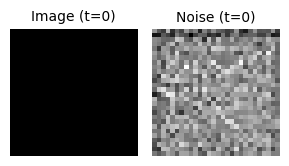

Generating images: 100%|██████████| 8/8 [05:25<00:00, 40.64s/it]


In [25]:
# Define paths and model parameters
model_path = '/content/drive/MyDrive/ddpm_unet.pth'
num_img_to_generate = 8           # Number of images to generate

# *** TASK 3 *** experiment with the number of reverse diffusion steps
num_timesteps = 2000

beta_start = 1e-4                 # Starting beta value for diffusion process
beta_end = 0.02                   # Ending beta value for diffusion process
image_size = 28                   # MNIST digits, so 28x28
in_channels = 1                   # MNIST digits, so just one channel
STEP_SIZE = 100                   # How often the visualization of the reverse
                                  # diffusion process should happen

# Initialize model and diffusion reverse process
model = Unet()
ddpmrp = DDPMReverseProcess(num_time_steps=num_timesteps, beta_start=beta_start, beta_end=beta_end)

# Load the best model weights
model.load_state_dict(torch.load(model_path, weights_only=True))
model = model.to(device)
model.eval()

# Generate images and visualize the denoising process
generated_images = []

for i in tqdm(range(num_img_to_generate), desc="Generating images"):
    # Start from random noise
    xt = torch.randn(1, in_channels, image_size, image_size).to(device)
    with torch.no_grad():
        # Reverse diffusion process
        for t in reversed(range(num_timesteps)):
            # Predict noise and update xt
            noise_pred = model(xt, torch.as_tensor(t).unsqueeze(0).to(device))
            xt, x0 = ddpmrp.sample_prev_timestep(xt, noise_pred, torch.as_tensor(t).to(device))

            # Visualize every STEP_SIZE timesteps
            if t % STEP_SIZE == 0:
                # Prepare images for visualization
                xt_image = torch.clamp(xt, -1., 1.).detach().cpu()
                xt_image = (xt_image + 1) / 2
                xt_image = 255 * xt_image[0][0].numpy()

                noise_pred_image = noise_pred.detach().cpu()[0][0].numpy()

                # Dynamic plotting
                clear_output(wait=True)
                fig, ax = plt.subplots(1, 2, figsize=(3, 3))

                ax[0].imshow(xt_image, cmap='gray', vmin=0, vmax=255)
                ax[0].set_title(f"Image (t={t})", fontsize=10)
                ax[0].axis('off')
                ax[0].set_aspect('equal')

                ax[1].imshow(noise_pred_image, cmap='gray', vmin=noise_pred_image.min(), vmax=noise_pred_image.max())
                ax[1].set_title(f"Noise (t={t})", fontsize=10)
                ax[1].axis('off')
                ax[1].set_aspect('equal')

                plt.tight_layout()
                plt.show()

    # Process the final generated image for storage
    xt = torch.clamp(xt, -1., 1.).detach().cpu()
    xt = (xt + 1) / 2
    xt = 255 * xt[0][0].numpy()

    # Append the final generated image to the list
    generated_images.append(xt)


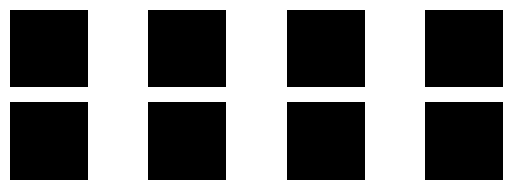

In [26]:
# Display all generated images
num_cols = num_img_to_generate // 2
num_rows = num_img_to_generate // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(6, 2))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_images[i], cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()